In [1]:
import torch
import torch.distributions as dist
import neml2
from pyzag import nonlinear, reparametrization, chunktime, stochastic
import matplotlib.pyplot as plt
import tqdm
import os
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import pyro
from pyro.infer import SVI, Trace_ELBO, Predictive

In [2]:
torch.set_default_dtype(torch.double)
if torch.cuda.is_available():
    dev = "cuda:0"
    print("CUDA is available")
    print(f"CUDA version: {torch.version.cuda}")
else:
    dev = "cpu"
    print("CUDA is not available")
device = torch.device(dev)

CUDA is available
CUDA version: 13.0


723K, 9.26e-05 1/s: strain range [0.0000, 0.0230]
523K, 9.26e-05 1/s: strain range [0.0000, 0.0523]
573K, 9.26e-05 1/s: strain range [0.0000, 0.0296]


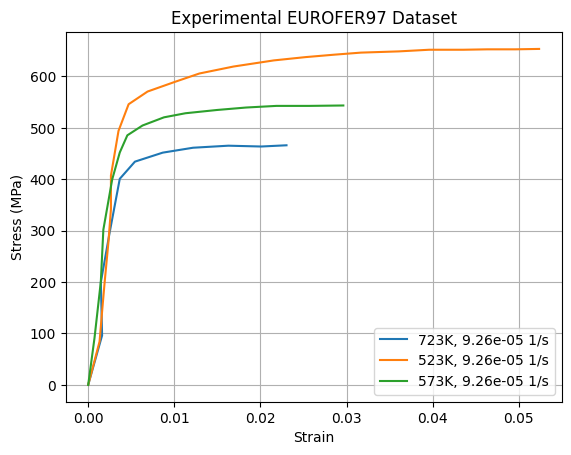

In [8]:
# Load experimental data
path = '/home/colinmg/neml2/cmg_projects/stress-strain/tensile_data/EUROFER97'
data_frames = {}
for filename in os.listdir(path):
    if filename.endswith(".csv"):
        file_path = os.path.join(path, filename)
        df = pd.read_csv(file_path)
        if '523' in filename:
            temp = 523
            strain_rate = 9.259e-5
            label = f'{temp}K, {strain_rate:.2e} 1/s'
        elif '573' in filename:
            temp = 573
            strain_rate = 9.259e-5
            label = f'{temp}K, {strain_rate:.2e} 1/s'
        elif '723' in filename:
            temp = 723
            strain_rate = 9.259e-5
            label = f'{temp}K, {strain_rate:.2e} 1/s'
        else:
            label = 'unknown'
        
        new_df = df.rename(columns={'x':f'{label}_strain', 'y':f'{label}_stress'})
        data_frames[label] = new_df

strain_data = {}
stress_data = {}

for label, df in data_frames.items():
    strain_col = f'{label}_strain'
    stress_col = f'{label}_stress'
    strain = torch.tensor(df[strain_col].values, device=device)
    stress = torch.tensor(df[stress_col].values, device=device)
    max_stress_idx = torch.argmax(stress).item()
    strain = strain[:max_stress_idx + 1]
    stress = stress[:max_stress_idx + 1]
    strain = strain[:] - strain[0]
    stress = stress[:] - stress[0]
    strain_data[label] = strain
    stress_data[label] = stress

exp_conditions = []
for label, df in data_frames.items():
    temp_str = label.split(',')[0]
    strain_rate_str = label.split(',')[1]

    temp = float(temp_str.replace('K', '').strip())
    strain_rate = float(strain_rate_str.replace('1/s', '').strip())
    exp_conditions.append((temp, strain_rate, label))

for i, (temp, rate, label) in enumerate(exp_conditions):
    min_strain = strain_data[label].min().item()
    max_strain = strain_data[label].max().item()
    
    # Experimental strain ranges
    print(f"{label}: strain range [{min_strain:.4f}, {max_strain:.4f}]")

# Plot initial dataset
plt.figure()
for label in strain_data:
    plt.plot(strain_data[label].cpu().numpy(), stress_data[label].cpu().numpy(), label=label)
plt.xlabel('Strain')
plt.ylabel('Stress (MPa)')
plt.title('Experimental EUROFER97 Dataset')
plt.grid()
plt.legend()
plt.show()

In [9]:
ntemperature = len(exp_conditions[0])
nrate = len(exp_conditions[1])
nbatch = len(exp_conditions)
ntime = 200
temperatures = torch.tensor([c[0] for c in exp_conditions], device=device)
rates = torch.tensor([c[1] for c in exp_conditions], device=device)

print(f"--- Initial Experimental Conditions ---\nstrain rates:\n{rates}\ntemperatures (K):\n{temperatures}")


--- Initial Experimental Conditions ---
strain rates:
tensor([9.2600e-05, 9.2600e-05, 9.2600e-05], device='cuda:0')
temperatures (K):
tensor([723., 523., 573.], device='cuda:0')


In [10]:
time = torch.zeros((ntime, nbatch, 1), device=device)
temperature = torch.zeros((ntime, nbatch, 1), device=device)
loading = torch.zeros((ntime, nbatch, 6), device=device)

for i, (temp, rate, label) in enumerate(exp_conditions):

    min_strain = strain_data[label].min().item()
    max_strain = strain_data[label].max().item()
    
    print(f"Temperature = {temp}K, rate = {rate:.2e} 1/s: strain range [{min_strain:.4f}, {max_strain:.4f}]")
    
    # Create loading (strain) values within this range
    strain_values = torch.linspace(min_strain, max_strain, ntime, device=device)
    time_values = torch.linspace(min_strain, max_strain/rate, ntime, device=device)
    loading[:, i, 0] = strain_values
    time[:, i, 0] = time_values
    
    # Set temperature (in Kelvin)
    temperature[:, i, 0] = temp

print(f"\n--- Full Input Tensors ---\ntime: {time.shape}\ntemperature: {temperature.shape}\nloading: {loading.shape}")


Temperature = 723.0K, rate = 9.26e-05 1/s: strain range [0.0000, 0.0230]
Temperature = 523.0K, rate = 9.26e-05 1/s: strain range [0.0000, 0.0523]
Temperature = 573.0K, rate = 9.26e-05 1/s: strain range [0.0000, 0.0296]

--- Full Input Tensors ---
time: torch.Size([200, 3, 1])
temperature: torch.Size([200, 3, 1])
loading: torch.Size([200, 3, 6])


Initial data size for 723K, 9.26e-05 1/s: torch.Size([11])
Initial data size for 523K, 9.26e-05 1/s: torch.Size([23])
Initial data size for 573K, 9.26e-05 1/s: torch.Size([15])
Interpolated data shape:
strain: torch.Size([200, 3, 6])
stress: torch.Size([200, 3, 6])
Saturated Stress values
[466.0039761431413, 653.386454183267, 543.3962264150944]


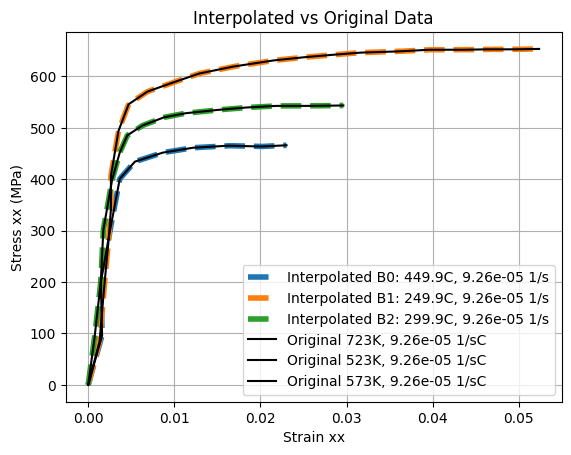

In [11]:
# Initial data shape
for label in strain_data:
    print(f"Initial data size for {label}: {stress_data[label].shape}")

exp_stress_data = torch.zeros_like(loading, device=device)
exp_strain_data = torch.zeros_like(loading, device=device)

for i, (temp, rate, label) in enumerate(exp_conditions):
    
    f_strain = torch.nn.functional.interpolate(strain_data[label].unsqueeze(0).unsqueeze(0), size=ntime, mode='linear', align_corners=True).squeeze()
    f_stress = torch.nn.functional.interpolate(stress_data[label].unsqueeze(0).unsqueeze(0), size=ntime, mode='linear', align_corners=True).squeeze()
    
    exp_strain_data[:, i, 0] = f_strain
    exp_stress_data[:, i, 0] = f_stress
    
print(f"Interpolated data shape:")
print(f"strain: {exp_strain_data.shape}")
print(f"stress: {exp_stress_data.shape}")

print("Saturated Stress values")
print(f"{[exp_stress_data[-1, i, 0].item() for i, _ in enumerate(temperatures)]:}")

# Plot interpolated data
plt.figure()
for i, T in enumerate(temperatures):
    temp_c = T.item() - 273.15
    rate_i = rates[i].item()
    label = f"B{i}: {temp_c:.1f}C, {rate_i:.2e} 1/s"
    plt.plot(exp_strain_data[:, i, 0].cpu().numpy(), exp_stress_data[:, i, 0].cpu().numpy(), '--', color=f'C{i}', lw=4, label=f"Interpolated {label}")
for label in strain_data:
    plt.plot(strain_data[label].cpu().numpy(), stress_data[label].cpu().numpy(), color='k', label=f"Original {label}C")
plt.xlabel("Strain xx")
plt.ylabel("Stress xx (MPa)")
plt.title("Interpolated vs Original Data")
plt.grid()
plt.legend()
plt.show()


In [12]:
class SolveStrain(torch.nn.Module):
    """Just integrate the model through some strain history

    Args:
        discrete_equations: the pyzag wrapped model
        nchunk (int): number of vectorized time steps
        rtol (float): relative tolerance to use for Newton's method during time integration
        atol (float): absolute tolerance to use for Newton's method during time integration
        initial_rho_m (float): initial mobile dislocation density (m^-2)
        debug_shapes (bool): print assembled tensor shapes before solve
    """

    def __init__(self, discrete_equations, nchunk=1, rtol=1.0e-6, atol=1.0e-4, initial_rho_m=6.0e2, debug_shapes=False):
        super().__init__()
        self.discrete_equations = discrete_equations
        self.nchunk = nchunk
        self.rtol = rtol
        self.atol = atol
        self.initial_rho_m = initial_rho_m
        self.debug_shapes = debug_shapes

    def forward(self, time, temperature, loading):
        """Integrate through some time/temperature/strain history and return stress
        Args:
            time (torch.tensor): batched times
            temperature (torch.tensor): batched temperatures
            loading (torch.tensor): loading conditions, which are the input strain in the first base index and then the stress (zero) in the remainder
        """
        solver = nonlinear.RecursiveNonlinearEquationSolver(
            self.discrete_equations,
            step_generator=nonlinear.StepGenerator(self.nchunk),
            predictor=nonlinear.PreviousStepsPredictor(),
            nonlinear_solver=chunktime.ChunkNewtonRaphson(rtol=self.rtol, atol=self.atol),
        )

        control = torch.zeros_like(loading)
        control[..., 1:] = 1.0

        # Setup
        forces = self.discrete_equations.forces_asm.assemble_by_variable(
            {
                "forces/t": time,
                "forces/control": control,
                "forces/T": temperature,
                "forces/fixed_values": loading,
            }
        ).torch()

        # Initialize state with non-zero rho_m to seed plastic flow.
        # assemble_by_variable fills unspecified variables with zeros automatically.
        state0 = self.discrete_equations.state_asm.assemble_by_variable(
            {
                "state/internal/rho_m": torch.full(
                    forces.shape[1:-1] + (1,), self.initial_rho_m, device=forces.device
                )
            }
        ).torch()

        if self.debug_shapes:
            print("--- SolveStrain shape debug ---")
            print(f"time shape: {tuple(time.shape)}")
            print(f"temperature shape: {tuple(temperature.shape)}")
            print(f"loading shape: {tuple(loading.shape)}")
            print(f"control shape: {tuple(control.shape)}")
            print(f"assembled forces shape: {tuple(forces.shape)}")
            print(f"assembled state0 shape: {tuple(state0.shape)}")
            print(f"len(forces): {len(forces)}")
            print(f"nchunk: {self.nchunk}")

            try:
                force_parts = self.discrete_equations.forces_asm.split_by_variable(neml2.Tensor(forces, 2))
                print("forces_asm split shapes:")
                for name, value in force_parts.items():
                    print(f"  {str(name)}: {tuple(value.torch().shape)}")
            except Exception as e:
                print(f"forces_asm split failed: {e}")

            try:
                state_parts = self.discrete_equations.state_asm.split_by_variable(neml2.Tensor(state0, 1))
                print("state_asm split shapes:")
                for name, value in state_parts.items():
                    print(f"  {str(name)}: {tuple(value.torch().shape)}")
            except Exception as e:
                print(f"state_asm split failed: {e}")

        result = nonlinear.solve_adjoint(solver, state0, len(forces), forces)

        # Check if result is empty or invalid
        if result is None or len(result) == 0:
            raise RuntimeError("Solver returned empty result - integration failed")

        # Return physical stress component explicitly instead of raw first state entry.
        state_hist_raw = self.discrete_equations.state_asm.split_by_variable(neml2.Tensor(result, 2))
        state_hist = {str(k): v.torch() for k, v in state_hist_raw.items()}

        if "state/mixed_state" in state_hist:
            return state_hist["state/mixed_state"][..., 0:1]

In [13]:
nmodel = neml2.load_model("new_model_tensile.i", "implicit_rate")
nmodel.to(device=device)
print(nmodel)
model = SolveStrain(neml2.pyzag.NEML2PyzagModel(nmodel, exclude_parameters=["E_a", "E_b", "E_c", "G_A", "G_bottom_A", "athermal_alpha", "athermal_b",
                                                                            "nu_a", "nu_b", "nu_c", "flow_rate_b", "shear_eff_m", "yield_sy", "v_disl_p",
                                                                            "v_disl_q", "v_disl_tau_p", "v_disl_H_0", "Bk_X", "C_X", "S_X", "T_0_X", "g_X",
                                                                            "k1_X", "k2_X"]))

Name:       implicit_rate
Input:      forces/T [Scalar]
            forces/control [SR2]
            forces/fixed_values [SR2]
            forces/t [Scalar]
            old_forces/control [SR2]
            old_forces/fixed_values [SR2]
            old_forces/t [Scalar]
            old_state/internal/X [SR2]
            old_state/internal/rho_m [Scalar]
            old_state/mixed_state [SR2]
            state/internal/X [SR2]
            state/internal/rho_m [Scalar]
            state/mixed_state [SR2]
Output:     residual/internal/X [SR2]
            residual/internal/rho_m [Scalar]
            residual/mixed_state [SR2]
Parameters: Bk_X [Scalar][Double][cuda:0]
            Bk_Y [Scalar][Double][cuda:0]
            C_X [Scalar][Double][cuda:0]
            C_Y [Scalar][Double][cuda:0]
            E_a [Scalar][Double][cuda:0]
            E_b [Scalar][Double][cuda:0]
            E_c [Scalar][Double][cuda:0]
            G_A [Scalar][Double][cuda:0]
            G_bottom_A [Scalar][Double][

In [14]:
actual_noise_scale = 10.0
n_repeat = 100
noisy_exp_stress_data = torch.stack([torch.normal(exp_stress_data, actual_noise_scale) for _ in range(n_repeat)])

Text(0.5, 1.0, 'EUROFER97 Dataset with Artificial Noise')

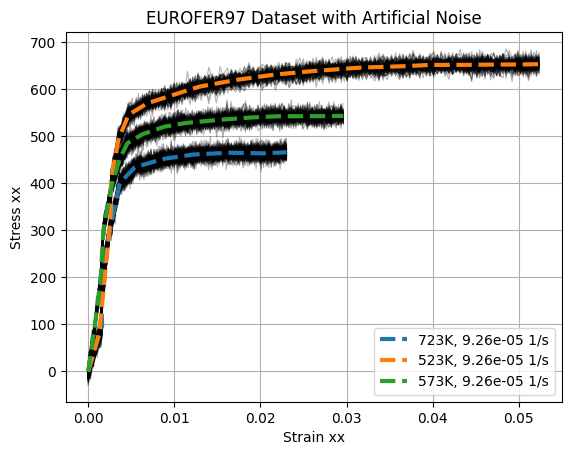

In [15]:
for repeat_idx in range(n_repeat):
    for i, T in enumerate(temperatures):
        t_label = str(int(T.item()))
        plt.plot(exp_strain_data[:, i, 0].cpu().numpy(), noisy_exp_stress_data[repeat_idx, :, i, 0].cpu().numpy(), color='k', alpha=0.3, lw=0.8)
for i, (T, rate, label) in enumerate(exp_conditions):
    plt.plot(exp_strain_data[:, i, 0].cpu().numpy(), exp_stress_data[:, i, 0].cpu().numpy(),'--', lw=3, color=f'C{i}', label=label)
plt.xlabel("Strain xx")
plt.ylabel("Stress xx")
plt.legend()
plt.grid()
plt.title("EUROFER97 Dataset with Artificial Noise")

In [16]:
initial_params = {}
print("--- Before Reparametrization ---")
for n, p in model.named_parameters():
    initial_params[n] = p.data.detach().clone()
    print(f"{n}: {p.data}, {p.shape}\n")

--- Before Reparametrization ---
discrete_equations.Bk_Y: tensor([6.6000e-06, 6.6000e-06, 6.6000e-06], device='cuda:0'), torch.Size([3])

discrete_equations.C_Y: tensor([5000., 5000., 5000.], device='cuda:0'), torch.Size([3])

discrete_equations.S_Y: tensor([30., 30., 30.], device='cuda:0'), torch.Size([3])

discrete_equations.T_0_Y: tensor([249.9387, 249.9387, 249.9387], device='cuda:0'), torch.Size([3])

discrete_equations.g_Y: tensor([30., 30., 30.], device='cuda:0'), torch.Size([3])

discrete_equations.k1_Y: tensor([5., 5., 5.], device='cuda:0'), torch.Size([3])

discrete_equations.k2_Y: tensor([3.5000, 3.5000, 3.5000], device='cuda:0'), torch.Size([3])



In [17]:
C_scaler = reparametrization.RangeRescale(torch.tensor([1500.0, 1500.0, 1500.0], device=device), torch.tensor([25000.0, 25000.0, 25000.0], device=device))
g_scaler = reparametrization.RangeRescale(torch.tensor([10.0, 10.0, 10.0], device=device), torch.tensor([100.0, 100.0, 100.0], device=device))
k1_scaler = reparametrization.RangeRescale(torch.tensor([0.1, 0.1, 0.1], device=device), torch.tensor([50.0, 50.0, 50.0], device=device))
k2_scaler = reparametrization.RangeRescale(torch.tensor([0.0001, 0.0001, 0.0001], device=device), torch.tensor([10.0, 10.0, 10.0], device=device))
Bk_scaler = reparametrization.RangeRescale(torch.tensor([1.0e-10, 1.0e-10, 1.0e-10], device=device), torch.tensor([1.0e-5, 1.0e-5, 1.0e-5], device=device))
T_0_scaler = reparametrization.RangeRescale(torch.tensor([100.0, 100.0, 100.0], device=device), torch.tensor([500.0, 500.0, 500.0], device=device))
s_scaler = reparametrization.RangeRescale(torch.tensor([0.01, 0.01, 0.01], device=device), torch.tensor([100.0, 100.0, 100.0], device=device))

model_reparameterizer = reparametrization.Reparameterizer(
    {"discrete_equations.C_Y" : C_scaler,
     "discrete_equations.g_Y" : g_scaler,
     "discrete_equations.k1_Y" : k1_scaler,
     "discrete_equations.k2_Y" : k2_scaler,
     "discrete_equations.Bk_Y" : Bk_scaler,
     "discrete_equations.T_0_Y" : T_0_scaler,
     "discrete_equations.S_Y" : s_scaler}, error_not_provided=True)
model_reparameterizer(model)
print(f'--- After Reparameterization ---')
initial_params_reparam = {}
for n, p in model.named_parameters():
    initial_params_reparam[n] = p.data.detach().clone()
    print(f'{n}: {p.data}, requires_grad={p.requires_grad}')

--- After Reparameterization ---
discrete_equations.parametrizations.Bk_Y.original: tensor([0.6600, 0.6600, 0.6600], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.C_Y.original: tensor([0.1489, 0.1489, 0.1489], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.S_Y.original: tensor([0.2999, 0.2999, 0.2999], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.T_0_Y.original: tensor([0.3748, 0.3748, 0.3748], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.g_Y.original: tensor([0.2222, 0.2222, 0.2222], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.k1_Y.original: tensor([0.0982, 0.0982, 0.0982], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.k2_Y.original: tensor([0.3500, 0.3500, 0.3500], device='cuda:0'), requires_grad=True


In [18]:
prior_cov = 0.05
prior_noise_scale = 10.0

mapper = stochastic.MapNormal(prior_cov)
hsmodel = stochastic.HierarchicalStatisticalModel(model, mapper, torch.tensor(prior_noise_scale, device = device))

In [19]:
nreps = 5
predict = Predictive(hsmodel, num_samples=nreps)
with torch.no_grad():
    untrained_all = predict(time, temperature, loading, )["obs"]

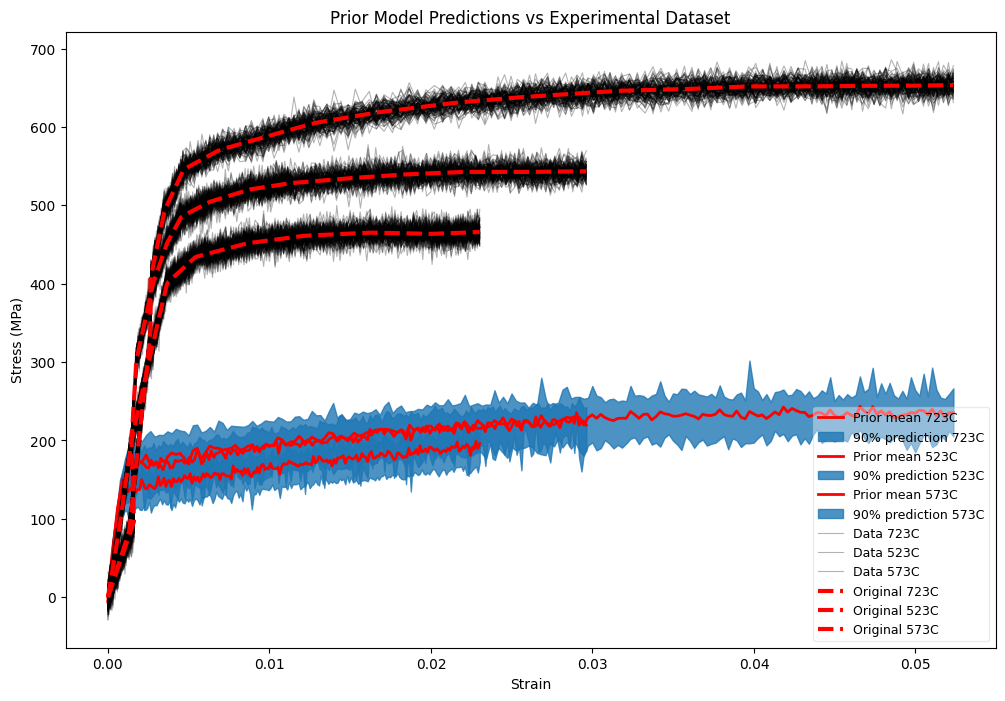

In [20]:
plt.figure(figsize=(12,8))
plotted_labels = set()
for i, T in enumerate(temperatures):
    t_label = str(int(T.item()))
    temp_preds = untrained_all[:, :, i, 0]
    plt.plot(loading[:, i, 0].cpu(), temp_preds.mean(dim=0).cpu(),
        ls="-",
        color="r",
        lw=2,
        label=f"Prior mean {t_label}C",
    )

    p = 0.05
    n_lb = max(1, int(p * nreps))
    n_ub = max(nreps, int((1 - p) * nreps) + 1)
    plt.fill_between(
        loading[:, i, 0].cpu(),
        torch.kthvalue(temp_preds, n_lb, dim=0)[0].cpu(),
        torch.kthvalue(temp_preds, n_ub, dim=0)[0].cpu(),
        color="tab:blue",
        alpha=0.8,
        label=f"90% prediction {t_label}C",
    )
for repeat_idx in range(n_repeat):
    for i, T in enumerate(temperatures):
        t_label = str(int(T.item()))
        label = f"Data {t_label}C" if f"Data {t_label}C" not in plotted_labels else None
        if label:
            plotted_labels.add(label)
        plt.plot(exp_strain_data[:, i, 0].cpu().numpy(), noisy_exp_stress_data[repeat_idx, :, i, 0].cpu().numpy(), 
                    color='k', alpha=0.3, lw=0.8, label=label)
for i, T in enumerate(temperatures):
    t_label = str(int(T.item()))
    plt.plot(exp_strain_data[:, i, 0].cpu().numpy(), exp_stress_data[:, i, 0].cpu().numpy(),'--', lw=3, color='r', label=f'Original {t_label}C')


plt.xlabel("Strain")
plt.ylabel("Stress (MPa)")
plt.title("Prior Model Predictions vs Experimental Dataset")
plt.legend(loc="best", framealpha=0.4, fontsize=9)
plt.show()

In [21]:
guide = pyro.infer.autoguide.guides.AutoDelta(hsmodel)
lr = 1.0e-3
niter = 200
num_samples = 1

optimizer = pyro.optim.ClippedAdam({'lr': lr})
loss = Trace_ELBO(num_particles=num_samples)
svi = SVI(hsmodel, guide, optimizer, loss = loss)

Loss: 8.19e+05: : 100%|██████████|200/200


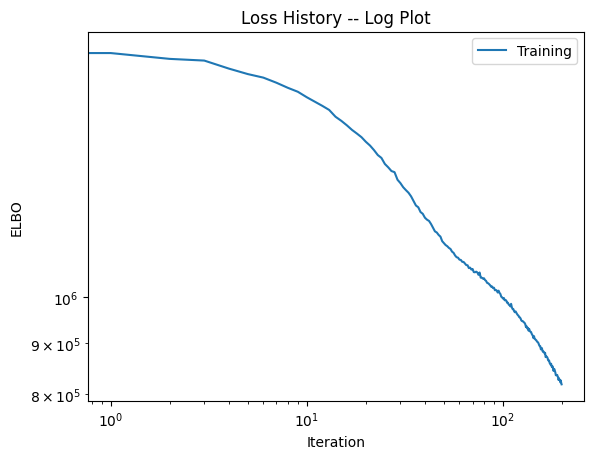

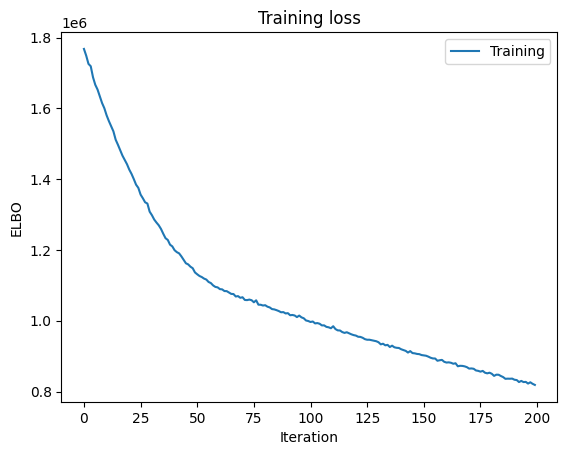

In [22]:
titer = tqdm.tqdm(
    range(niter),
    bar_format="{desc}: {percentage:3.0f}%|{bar}|{n_fmt}/{total_fmt}{postfix}",
)
titer.set_description("Loss:")
loss_history = []
for i in titer:
    batch_idx = torch.randint(0, noisy_exp_stress_data.shape[0], (1,), device=device).item()
    batch_results = noisy_exp_stress_data[batch_idx]
    closs = svi.step(time, temperature, loading, results=batch_results)
    loss_history.append(closs)
    titer.set_description("Loss: %3.2e" % closs)

plt.figure()
plt.loglog(loss_history, label='Training')
plt.xlabel('Iteration')
plt.ylabel('ELBO')
plt.legend(loc='best')
plt.title('Loss History -- Log Plot')

plt.figure()
plt.plot(loss_history, label="Training")
plt.xlabel("Iteration")
plt.ylabel("ELBO")
plt.legend(loc="best")
plt.title("Training loss")
plt.show()

In [23]:
nreps = 5
predict = Predictive(hsmodel, guide=guide, num_samples=nreps)
with torch.no_grad():
    trained_all = predict(time, temperature, loading, )["obs"]

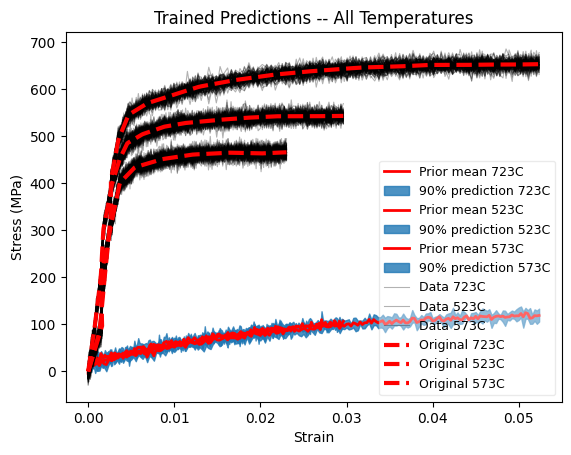

In [24]:
plt.figure()
plotted_labels = set()
for i, T in enumerate(temperatures):
    t_label = str(int(T.item()))
    temp_preds = trained_all[:, :, i, 0]
    plt.plot(loading[:, i, 0].cpu(), temp_preds.mean(dim=0).cpu(),
        ls="-",
        color="r",
        lw=2,
        label=f"Prior mean {t_label}C",
    )

    p = 0.05
    n_lb = max(1, int(p * nreps))
    n_ub = max(nreps, int((1 - p) * nreps) + 1)
    plt.fill_between(
        loading[:, i, 0].cpu(),
        torch.kthvalue(temp_preds, n_lb, dim=0)[0].cpu(),
        torch.kthvalue(temp_preds, n_ub, dim=0)[0].cpu(),
        color="tab:blue",
        alpha=0.8,
        label=f"90% prediction {t_label}C",
    )
for repeat_idx in range(n_repeat):
    for i, T in enumerate(temperatures):
        t_label = str(int(T.item()))
        label = f"Data {t_label}C" if f"Data {t_label}C" not in plotted_labels else None
        if label:
            plotted_labels.add(label)
        plt.plot(exp_strain_data[:, i, 0].cpu().numpy(), noisy_exp_stress_data[repeat_idx, :, i, 0].cpu().numpy(), 
                    color='k', alpha=0.3, lw=0.8, label=label)
for i, T in enumerate(temperatures):
    t_label = str(int(T.item()))
    plt.plot(exp_strain_data[:, i, 0].cpu().numpy(), exp_stress_data[:, i, 0].cpu().numpy(),'--', lw=3, color='r', label=f'Original {t_label}C')


plt.xlabel("Strain")
plt.ylabel("Stress (MPa)")
plt.title("Trained Predictions -- All Temperatures")
plt.legend(loc="best", framealpha=0.4, fontsize=9)
plt.show()

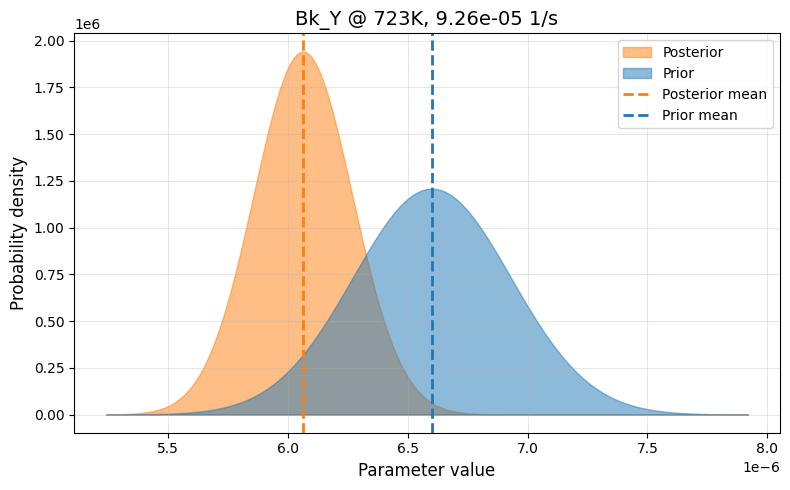

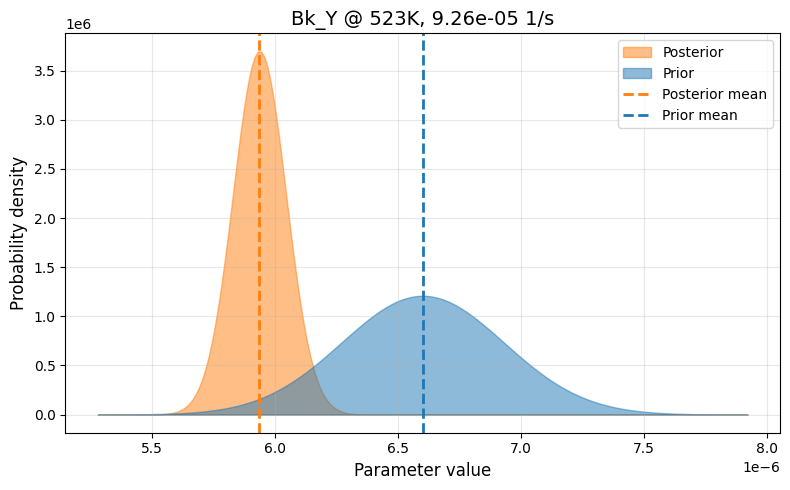

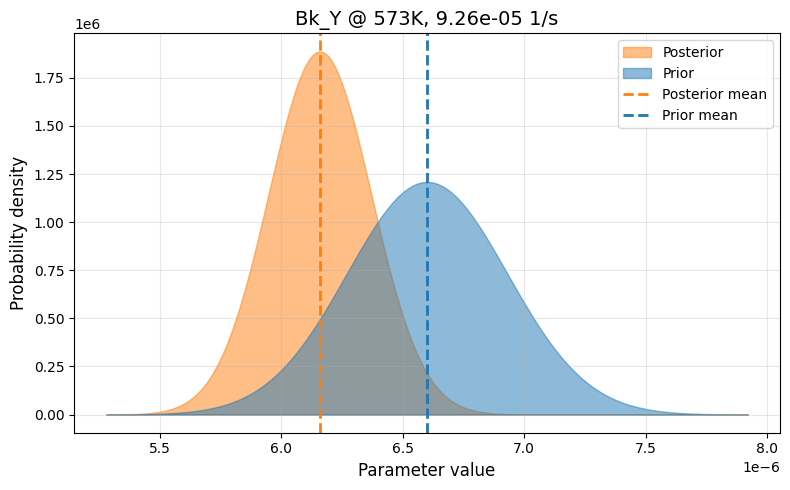

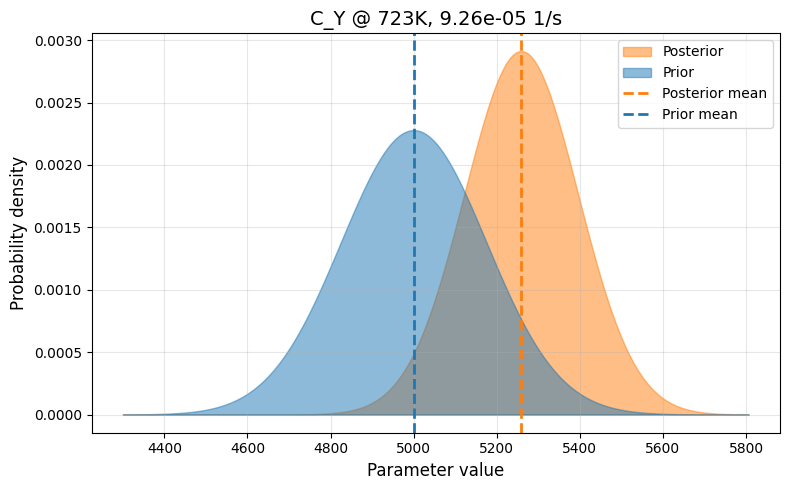

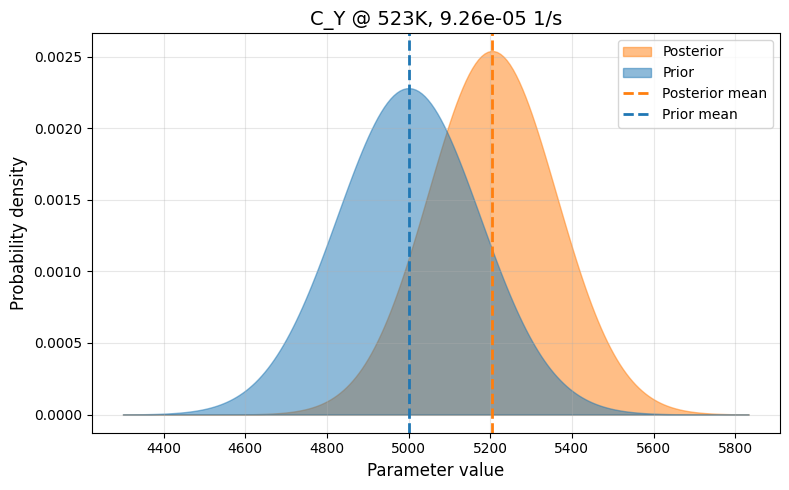

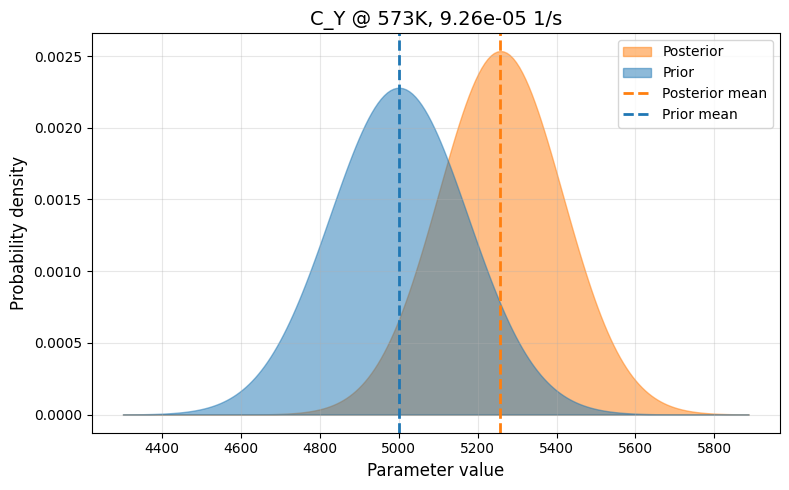

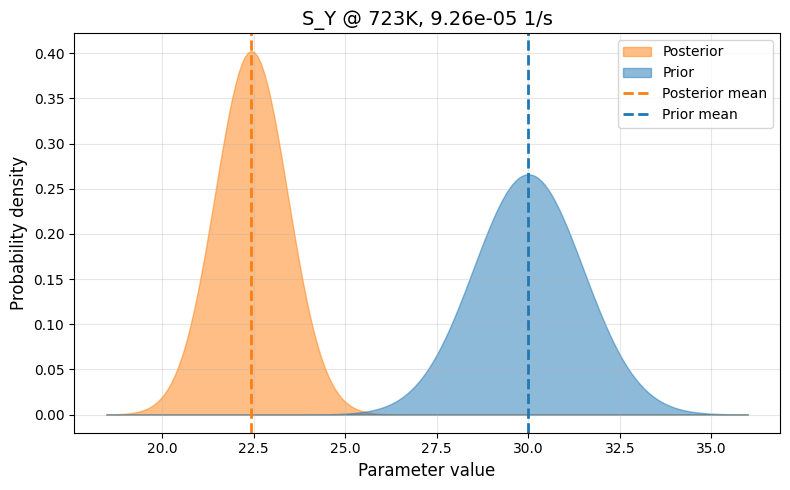

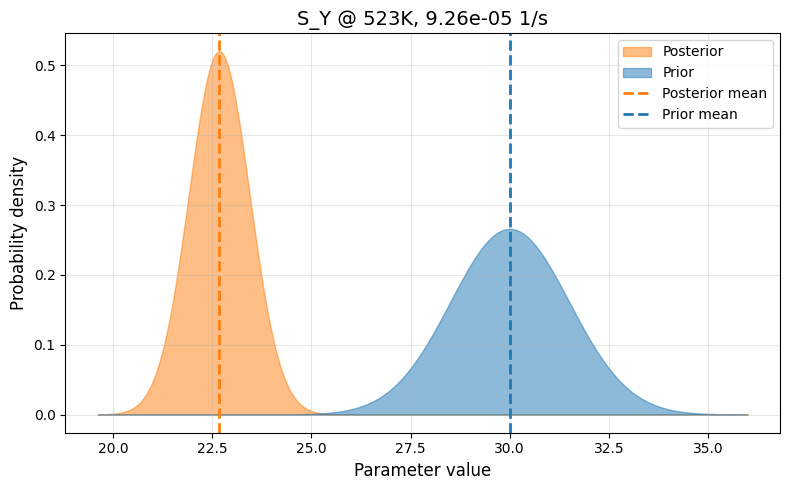

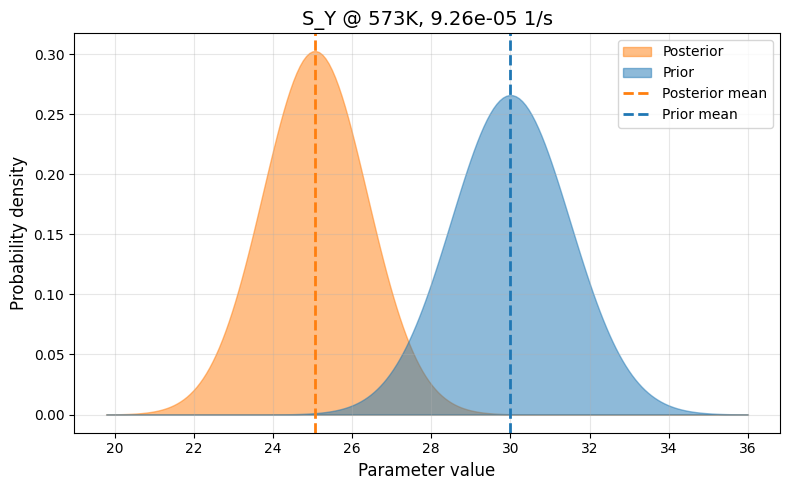

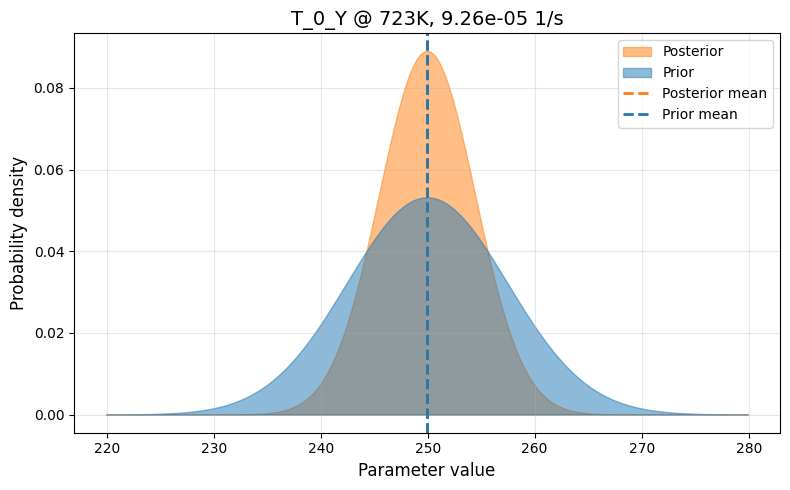

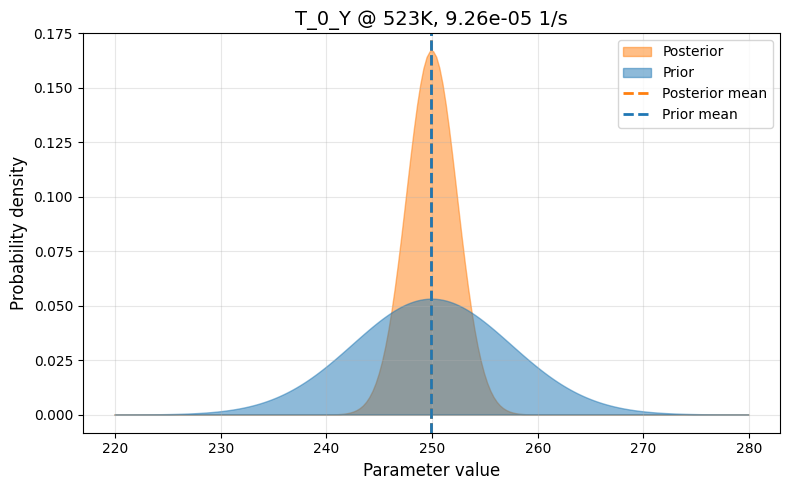

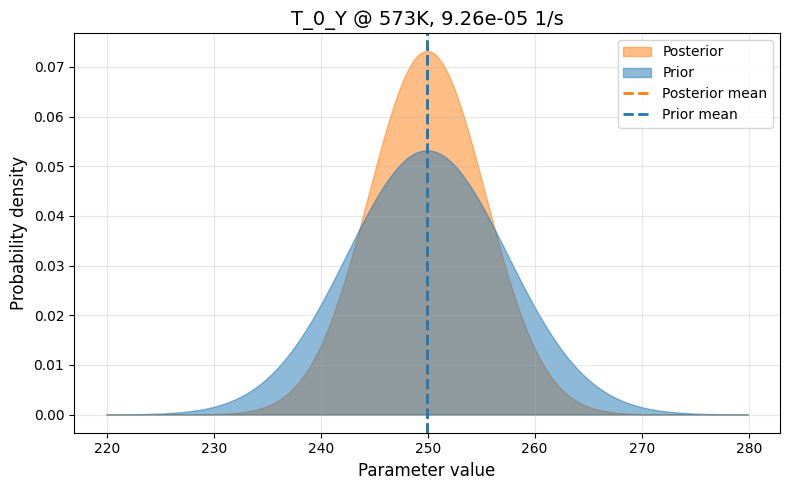

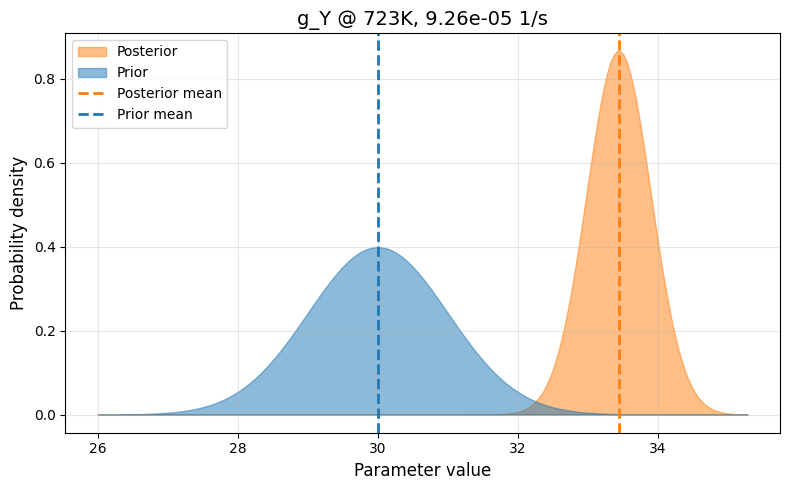

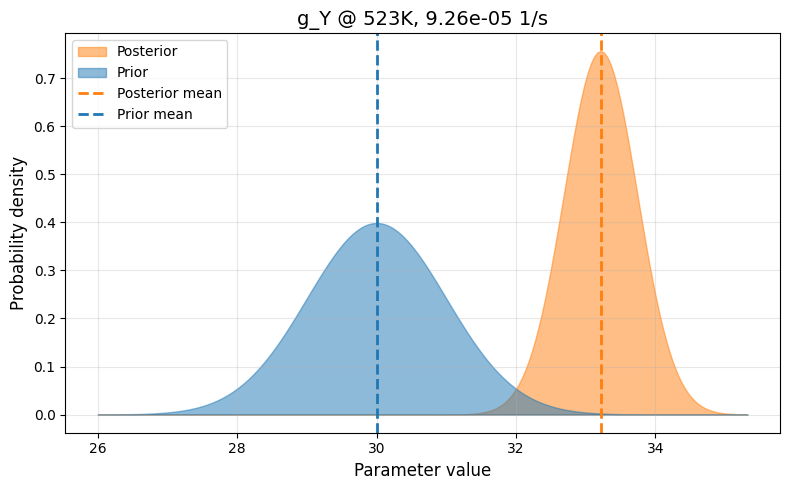

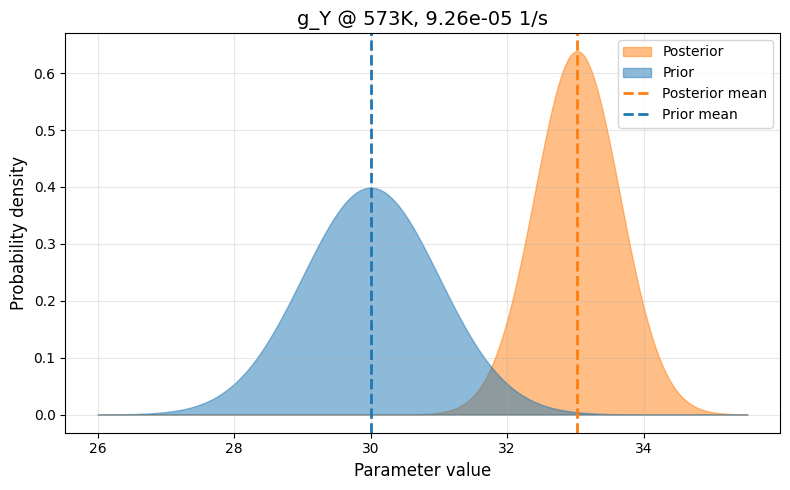

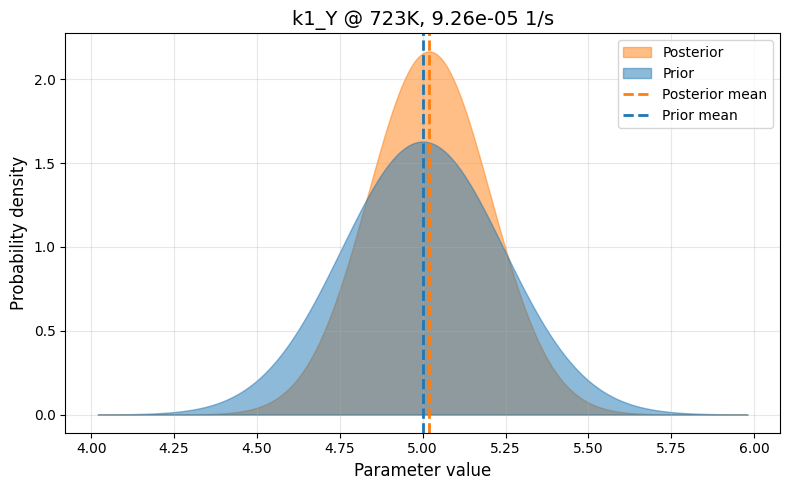

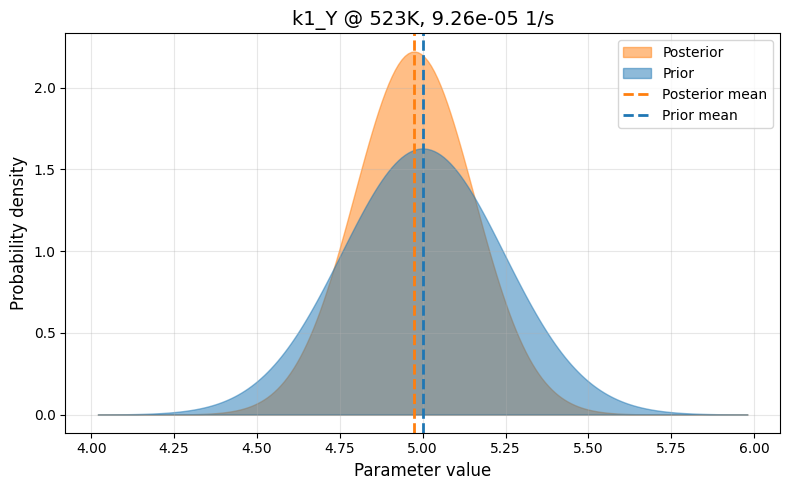

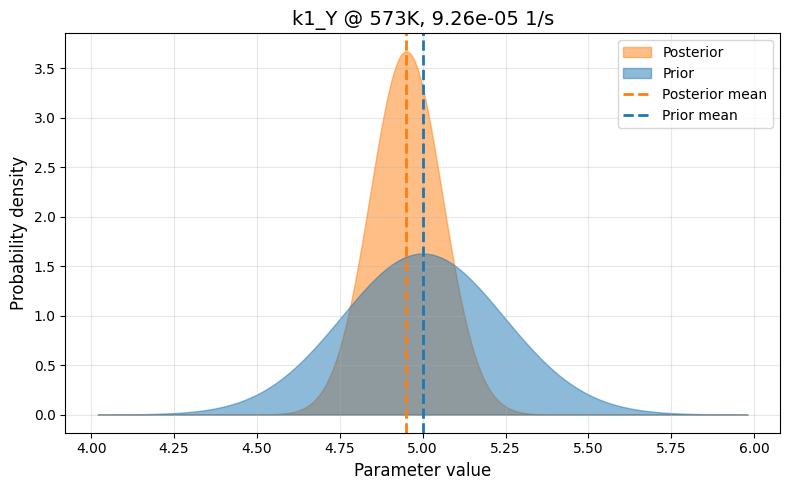

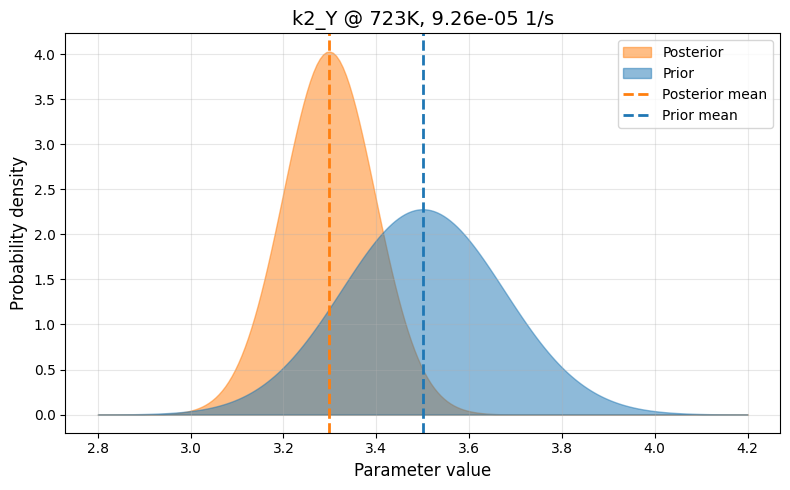

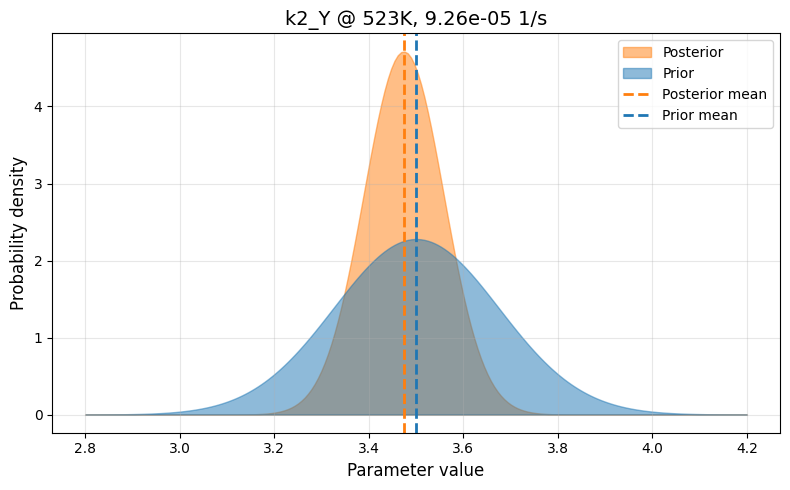

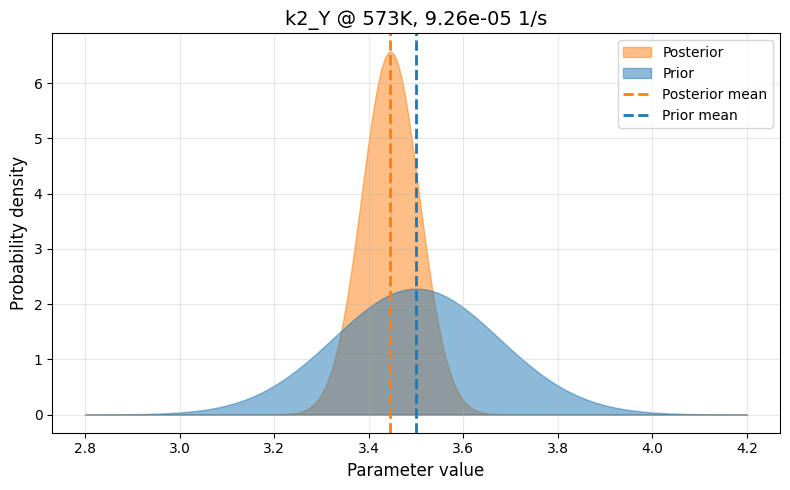

In [25]:
for _,_,n in hsmodel.bot:
    parts = n.split(".")
    if "parametrizations" in parts:
        param_idx = parts.index("parametrizations")
        simple_name = parts[param_idx - 1] + "." + parts[param_idx + 1]
    else:
        simple_name = '.'.join(parts[1:])
    
    scaler = model_reparameterizer.map_dict[simple_name]

    # ── Prior: transform from reparam space → parameter space ────────────────
    prior_loc_reparam  = initial_params_reparam[n].to(device)
    prior_loc          = scaler.forward(prior_loc_reparam)                    # <-- transform loc
    prior_scale_reparam = prior_cov * torch.abs(prior_loc_reparam)
    prior_scale        = scaler.forward_std_dev(prior_scale_reparam)          # <-- transform scale

    # ── Posterior: already being transformed correctly ────────────────────────
    posterior_loc   = scaler.forward(pyro.param("AutoDelta." + n + "_loc").detach())
    posterior_scale = scaler.forward_std_dev(pyro.param("AutoDelta." + n + "_scale").detach())

    param_name = simple_name.split('.')[-1]

    if posterior_loc.dim() == 0:
        x_range = torch.linspace(
            min(posterior_loc - 4*posterior_scale, prior_loc - 4*prior_scale),
            max(posterior_loc + 4*posterior_scale, prior_loc + 4*prior_scale),
            200, device=device
        )
        y_posterior = dist.Normal(posterior_loc, posterior_scale).log_prob(x_range).exp()
        y_prior     = dist.Normal(prior_loc,     prior_scale).log_prob(x_range).exp()

        plt.figure(figsize=(8, 5))
        plt.fill_between(x_range.cpu(), y_posterior.cpu(), label="Posterior", alpha=0.5, color='C1')
        plt.fill_between(x_range.cpu(), y_prior.cpu(),     label="Prior",     alpha=0.5, color='C0')
        plt.axvline(posterior_loc.cpu(), color='C1', linestyle='--', linewidth=2, label='Posterior mean')
        plt.axvline(prior_loc.cpu(),     color='C0', linestyle='--', linewidth=2, label='Prior mean')
        plt.xlabel('Parameter value', fontsize=12)
        plt.ylabel('Probability density', fontsize=12)
        plt.legend(loc='best', fontsize=10)
        plt.title(f'{param_name}', fontsize=14)
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:

        # ── Simpler label extraction (no need for enumerate + append) ─────────────────
        labels = [label for _, _, label in exp_conditions]

        # ── Sanity check: confirm shape matches ───────────────────────────────────────
        assert posterior_loc.shape[0] == len(labels), (
            f"Mismatch: posterior has {posterior_loc.shape[0]} dims "
            f"but got {len(labels)} labels: {labels}")
    
        for i in range(posterior_loc.shape[0]):
            x_range = torch.linspace(
                min(posterior_loc[i] - 4*posterior_scale[i], prior_loc[i] - 4*prior_scale[i]),
                max(posterior_loc[i] + 4*posterior_scale[i], prior_loc[i] + 4*prior_scale[i]),
                200, device=device
            )
            y_posterior = dist.Normal(posterior_loc[i], posterior_scale[i]).log_prob(x_range).exp()
            y_prior     = dist.Normal(prior_loc[i],     prior_scale[i]).log_prob(x_range).exp()

            plt.figure(figsize=(8, 5))
            plt.fill_between(x_range.cpu(), y_posterior.cpu(), label="Posterior", alpha=0.5, color='C1')
            plt.fill_between(x_range.cpu(), y_prior.cpu(),     label="Prior",     alpha=0.5, color='C0')
            plt.axvline(posterior_loc[i].cpu(), color='C1', linestyle='--', linewidth=2, label='Posterior mean')
            plt.axvline(prior_loc[i].cpu(),     color='C0', linestyle='--', linewidth=2, label='Prior mean')
            plt.xlabel('Parameter value', fontsize=12)
            plt.ylabel('Probability density', fontsize=12)
            plt.legend(loc='best', fontsize=10)
            plt.title(f'{param_name} @ {labels[i]}', fontsize=14)
            plt.grid(alpha=0.3)
            plt.tight_layout()
            plt.show()